In [ ]:
import os
from roboflow import Roboflow
from ultralytics import YOLO
from google.colab import files, userdata


api_key = userdata.get('rf')
rf = Roboflow(api_key=api_key)
project = rf.workspace("seif-fhpbi").project("drivers-drowsiness-detection-pnkke")
dataset = project.version(2).download("yolov8")





loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Drivers-Drowsiness-Detection-2 in yolov8:: 100%|██████████| 45455/45455 [00:08<00:00, 5641.42it/s] 


In [ ]:

yaml_path = os.path.join(dataset.location, "data.yaml")
with open(yaml_path, 'r') as file:
    lines = file.readlines()

with open(yaml_path, 'w') as file:
    for line in lines:
        if line.startswith("train:") and not line.strip().endswith("train/images"):
            file.write(f"train: {dataset.location}/train/images\n")
        elif line.startswith("val:") and not line.strip().endswith("valid/images"):
            file.write(f"val: {dataset.location}/valid/images\n")
        elif line.startswith("test:") and not line.strip().endswith("test/images"):
            file.write(f"test: {dataset.location}/test/images\n")
        else:
            file.write(line)

In [ ]:

model = YOLO("yolov8n.pt")


results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    plots=True
)



print("--- Launching local download for best.pt weights... ---")
files.download('/content/runs/detect/train/weights/best.pt')

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Drivers-Drowsiness-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the source path (YOLOv8 default output) and the destination in Drive
source_path = '/content/runs/detect/train/weights/best.pt'
drive_destination = '/content/drive/MyDrive/yolov8_drowsiness_model/'

# Create the destination directory if it doesn't exist
os.makedirs(drive_destination, exist_ok=True)

# 3. Copy the file
try:
    shutil.copy(source_path, os.path.join(drive_destination, 'best.pt'))
    print(f"Successfully saved model to: {drive_destination}best.pt")
except FileNotFoundError:
    print("Error: The trained weights file was not found. Please ensure training completed successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully saved model to: /content/drive/MyDrive/yolov8_drowsiness_model/best.pt


### Run Predictions on Test Dataset
We will now use the trained model to predict drowsiness on the images in the `test` set and display a few examples.

In [ ]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Load the best performing model weights
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Run inference on the test images
# We'll save the results to a new folder called 'test_predictions'
test_images_path = os.path.join(dataset.location, 'test/images')
results = model.predict(source=test_images_path, save=True, conf=0.25, project='test_results', name='test_predictions')

# 3. Display a few sample predictions
prediction_images = glob.glob('/content/test_results/test_predictions/*.jpg')

if prediction_images:
    plt.figure(figsize=(20, 10))
    for i, img_path in enumerate(prediction_images[:3]):  # Show first 3 samples
        plt.subplot(1, 3, i + 1)
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Sample Prediction {i+1}")
    plt.show()
else:
    print("No prediction images found to display.")


image 1/948 /content/Drivers-Drowsiness-Detection-2/test/images/221023-091302_jpg.rf.238bdad1f82a02636b34c513f2f30df8.jpg: 640x640 1 drowsy, 8.1ms
image 2/948 /content/Drivers-Drowsiness-Detection-2/test/images/221023-091305_jpg.rf.5808471ad92fabf057221a4c3059c72f.jpg: 640x640 1 drowsy, 7.2ms
image 3/948 /content/Drivers-Drowsiness-Detection-2/test/images/221023-091311_jpg.rf.177c99f582e1f70c2481c42cc1f637e3.jpg: 640x640 1 awake, 7.2ms
image 4/948 /content/Drivers-Drowsiness-Detection-2/test/images/221023-091337_jpg.rf.9fd6a00225735c2c2768623c3ac90fca.jpg: 640x640 1 drowsy, 7.2ms
image 5/948 /content/Drivers-Drowsiness-Detection-2/test/images/221023-091338_jpg.rf.43842e789b455837ba812a0826c069ae.jpg: 640x640 1 drowsy, 7.2ms
image 6/948 /content/Drivers-Drowsiness-Detection-2/test/images/221023-091400_jpg.rf.ef738d11beb980fec24f2d9e9845a113.jpg: 640x640 1 drowsy, 7.2ms
image 7/948 /content/Drivers-Drowsiness-Detection-2/test/images/221023-091401_jpg.rf.5dbbfb0e16615fe018fa10f30c32ca28.

### Model Evaluation: Confusion Matrix
We will now run the model validation to calculate precision metrics and visualize the confusion matrix.

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1241.9±559.8 MB/s, size: 39.4 KB)
val: Scanning /content/Drivers-Drowsiness-Detection-2/valid/labels.cache... 1890 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1890/1890 660.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 119/119 6.2it/s 19.3s
                   all       1890       1890      0.989      0.988      0.992      0.906
                 awake        809        809      0.987      0.986       0.99      0.909
                drowsy       1081       1081       0.99      0.989      0.993      0.904
Speed: 1.2ms preprocess, 3.8ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-2


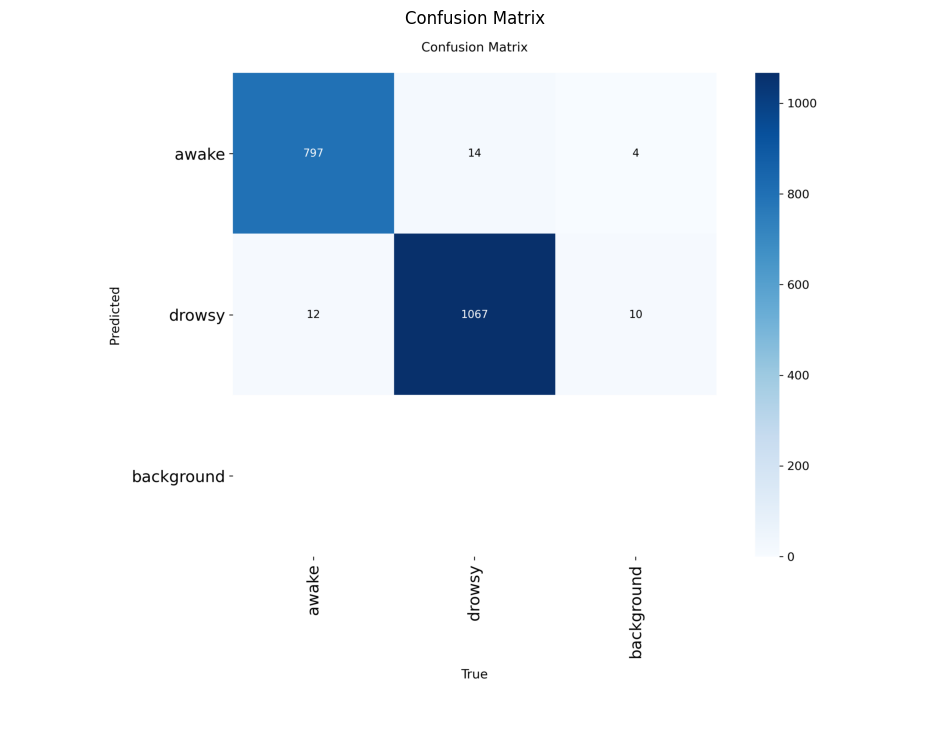

Validation Results summary:
mAP50: 0.9919
mAP50-95: 0.9065


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 1. Run validation using the best weights
val_results = model.val(data=yaml_path, split='val')

# 2. Locate and display the Confusion Matrix
# The matrix is typically saved in 'runs/detect/val/' or the specific train run folder
val_dir = val_results.save_dir
confusion_matrix_path = os.path.join(val_dir, 'confusion_matrix.png')

if os.path.exists(confusion_matrix_path):
    plt.figure(figsize=(12, 10))
    img = mpimg.imread(confusion_matrix_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Confusion Matrix")
    plt.show()
else:
    print(f"Confusion matrix not found at {confusion_matrix_path}. Checking fallback directories...")
    # Fallback search if path mismatch occurs
    import glob
    possible_files = glob.glob('runs/detect/**/confusion_matrix.png', recursive=True)
    if possible_files:
        latest_file = max(possible_files, key=os.path.getmtime)
        img = mpimg.imread(latest_file)
        plt.imshow(img)
        plt.axis('off')
        plt.show()

# 3. Output summary metrics
print(f"Validation Results summary:")
print(f"mAP50: {val_results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95: {val_results.results_dict['metrics/mAP50-95(B)']:.4f}")